# M2 Round 2A — Python-native EDA

Issue: [#26](../../../issues/26) — Round 2, Approach A of M2's EDA parallel track.

**Which Round 1 output this builds on, and why:** at the time this notebook was built, only
Round 1 Path A (Giti's sequential pull, PR #35) exists as working, reviewed output. Round 1 Path B
(Lerneir's concurrent client classes, issue #24) has no branch or PR yet, so there is no second
candidate to compare against — this notebook uses Path A's `data/processed/` output by default,
not by a judged comparison. If Path B lands before the Round 2 team sync, this choice should be
revisited.

**Scope** (per issue #26 definition of done): distributions, a missingness map, a correlation
matrix, ADF stationarity pre-checks, and at least 3 candidate figures with enough interpretation
to be useful to the rest of the team.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

sns.set_theme(style="whitegrid")
PROJECT_ROOT = Path.cwd().resolve().parents[1]
PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED


WindowsPath('C:/Users/User/OneDrive/Documentos/Master in data analytics/Capstone Project/data/processed')

## 1. Load the three processed sources

- `bank_of_canada_data.csv` — BoC policy/yield-curve series, daily, business days
- `fred_rates.csv` — US 10y treasury + fed funds rate, daily, business days
- `statcan_cpi.csv` — Canadian CPI, **monthly**, with both `reference_month` (the period the
  number describes) and `release_date` (when it was actually published — StatCan publishes CPI
  with roughly a 3-week lag)


In [2]:
boc = pd.read_csv(PROCESSED / "bank_of_canada_data.csv", parse_dates=["date"])
fred = pd.read_csv(PROCESSED / "fred_rates.csv", parse_dates=["date"])
cpi = pd.read_csv(PROCESSED / "statcan_cpi.csv", parse_dates=["reference_month", "release_date"])

for name, df in [("boc", boc), ("fred", fred), ("cpi", cpi)]:
    print(f"{name}: {df.shape}, {df.iloc[:, 0].min().date()} -> {df.iloc[:, 0].max().date()}")


boc: (4552, 12), 2009-01-02 -> 2026-06-30
fred: (4563, 3), 2009-01-02 -> 2026-06-30
cpi: (210, 3), 2009-01-01 -> 2026-06-01


## 2. Aligning three different frequencies onto one daily frame

BoC and FRED are both daily (business-day) series and merge on `date` directly. CPI is monthly
and, naively left-joined onto a daily index by `reference_month`, would show as "missing" on
every day that isn't the 1st of the month — that's not a data quality problem, it's a frequency
mismatch, and the missingness map in the next section would be misleading without correcting for
it here.

Instead, CPI is forward-filled onto the daily index keyed on **`release_date`**, not
`reference_month`: a CPI print only becomes actual public information on the day StatCan
publishes it (about 3 weeks after the reference month ends), so aligning on `reference_month`
would leak information the market didn't have yet on that date. This mirrors the release-date
mapping work already done in `config/cpi_release_dates.csv` (PR #35) and matters for any
downstream modeling that treats these as a real-time information set.


In [3]:
daily = boc.merge(fred, on="date", how="outer").sort_values("date")

# YoY inflation is computed at CPI's native monthly frequency (reference_month order) before
# merging — pct_change on the forward-filled daily series would divide by 250-253 varying
# business days per year instead of a clean 12-month lag, producing spurious jumps.
cpi_monthly = cpi.sort_values("reference_month").copy()
cpi_monthly["cpi_yoy"] = cpi_monthly["cpi_all_items"].pct_change(12) * 100

cpi_daily = cpi_monthly[["release_date", "cpi_all_items", "cpi_yoy"]].rename(columns={"release_date": "date"})
cpi_daily = cpi_daily.sort_values("date")

daily = daily.merge(cpi_daily, on="date", how="left").sort_values("date").reset_index(drop=True)
daily["cpi_all_items"] = daily["cpi_all_items"].ffill()
daily["cpi_yoy"] = daily["cpi_yoy"].ffill()

daily = daily.set_index("date")
daily.tail()


,overnight_rate,yield_2y,yield_3y,yield_5y,yield_7y,yield_10y,yield_long,usdcad_legacy,usdcad_current,usdcad,yield_spread_10y_2y,us_treasury_10y,fed_funds_rate,cpi_all_items,cpi_yoy
date,,,,,,,,,,,,,,,
2026-06-24,2.25,2.73,2.83,2.99,3.13,3.36,3.76,NaN,1.4234,1.4234,0.63,4.41,3.63,169.6,3.225806
2026-06-25,2.25,2.75,2.85,3.02,3.16,3.39,3.79,NaN,1.4204,1.4204,0.64,4.40,3.63,169.6,3.225806
2026-06-26,2.25,2.75,2.85,3.02,3.15,3.39,3.80,NaN,1.4186,1.4186,0.64,4.38,3.63,169.6,3.225806
2026-06-29,2.25,2.73,2.83,3.00,3.13,3.37,3.77,NaN,1.4206,1.4206,0.64,4.38,3.63,169.6,3.225806
2026-06-30,2.25,2.74,2.84,3.01,3.14,3.38,3.77,NaN,1.4210,1.4210,0.64,4.44,3.63,169.6,3.225806


## 3. Missingness map

Three distinct causes are expected, and the point of this map is to tell them apart rather than
flag everything as one undifferentiated "missing data" problem:

1. **`usdcad_legacy` / `usdcad_current`** — BoC switched USD/CAD series on 2017-05-01; each column
   is structurally null on the other side of that date by design (see PR #35). `usdcad` is the
   stitched column and should have far fewer gaps.
2. **`cpi_all_items` / `cpi_yoy`** — null only before the first CPI release date lands (start of
   sample) and for the first 12 months of releases, where `pct_change(12)` on the monthly series
   has no prior-year value to compare against; not a collection defect.
3. **Everything else (`yield_2y` … `us_treasury_10y`)** — small, scattered gaps (~180 rows out of
   ~4,550) most likely bank holidays that don't line up 1:1 between BoC/FRED calendars, worth a
   spot check but not a Round 1 blocker.


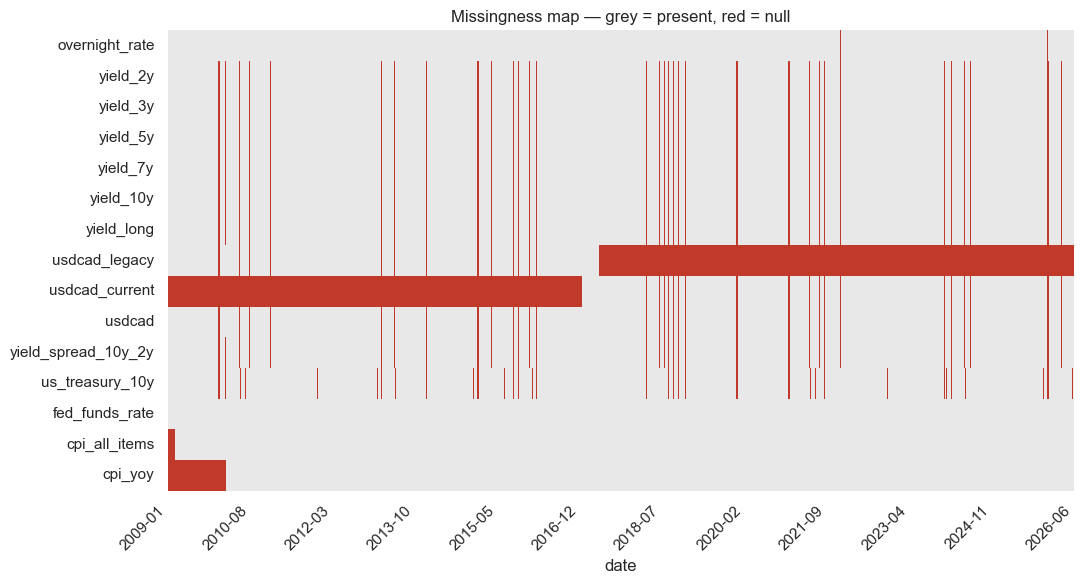

,n_missing,pct
overnight_rate,13,0.28
yield_2y,195,4.27
yield_3y,195,4.27
yield_5y,195,4.27
yield_7y,195,4.27
yield_10y,195,4.27
yield_long,195,4.27
usdcad_legacy,2478,54.31
usdcad_current,2194,48.08
usdcad,191,4.19


In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(daily.isna().T, cbar=False, cmap=["#e8e8e8", "#c0392b"], ax=ax)
ax.set_title("Missingness map — grey = present, red = null")
ax.set_xlabel("date")
tick_idx = np.linspace(0, len(daily) - 1, 12).astype(int)
ax.set_xticks(tick_idx)
ax.set_xticklabels(daily.index[tick_idx].strftime("%Y-%m"), rotation=45, ha="right")
fig.tight_layout()
plt.show()

daily.isna().sum().to_frame("n_missing").assign(pct=lambda d: (d["n_missing"] / len(daily) * 100).round(2))


## 4. Yield curve overview

Before treating each tenor as an isolated feature column, look at the actual subject of this
project: the term structure itself, and the slope summary (`yield_spread_10y_2y`) that's used
throughout the proposal as the primary modeling target. The top panel overlays all six GoC tenors;
the bottom panel is the 10y-2y spread, with the inverted region shaded.


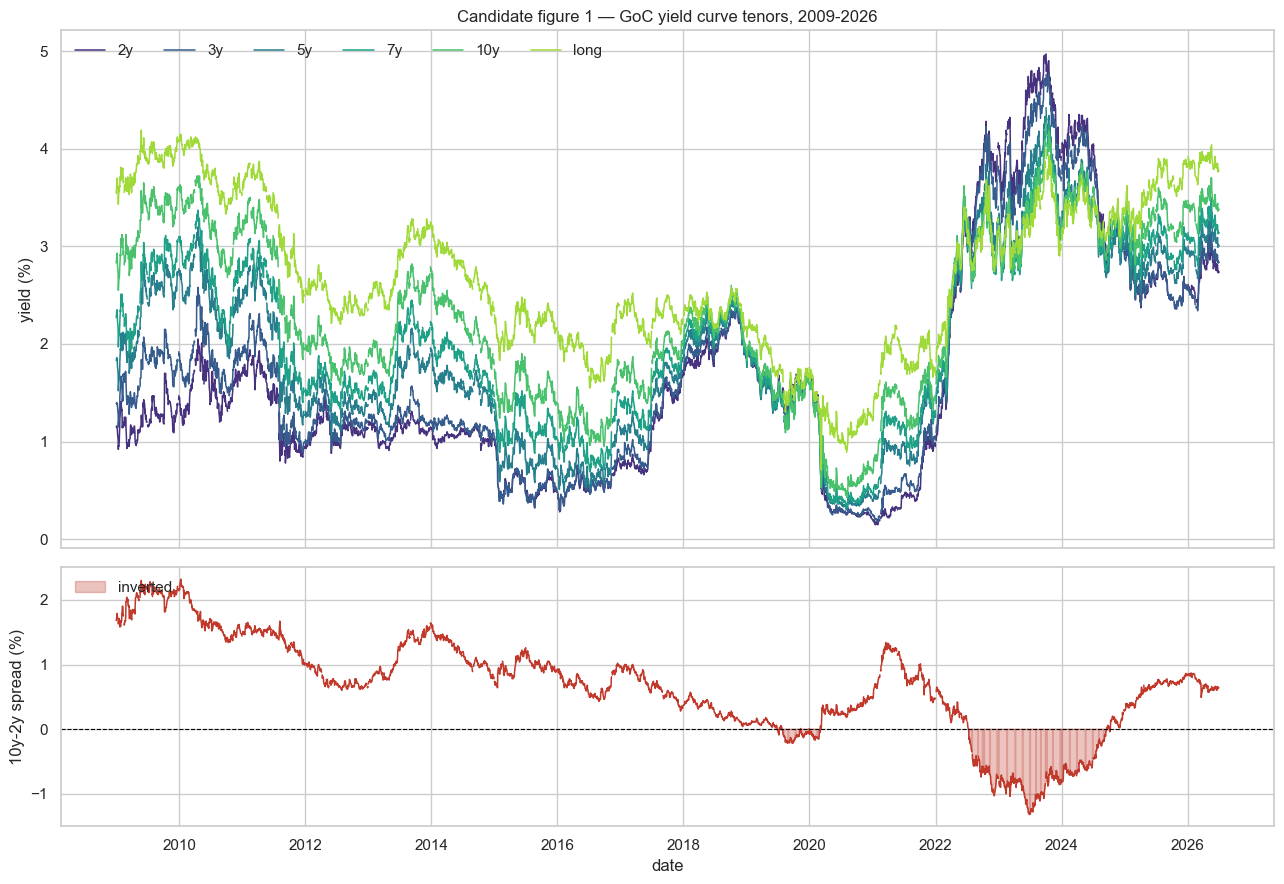

In [5]:
tenor_cols = ["yield_2y", "yield_3y", "yield_5y", "yield_7y", "yield_10y", "yield_long"]
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

palette = sns.color_palette("viridis", n_colors=len(tenor_cols))
for col, color in zip(tenor_cols, palette):
    axes[0].plot(daily.index, daily[col], label=col.replace("yield_", ""), color=color, linewidth=1.1)
axes[0].set_ylabel("yield (%)")
axes[0].set_title("Candidate figure 1 — GoC yield curve tenors, 2009-2026")
axes[0].legend(ncol=6, loc="upper left", frameon=False)

axes[1].plot(daily.index, daily["yield_spread_10y_2y"], color="#c0392b", linewidth=1.1)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].fill_between(
    daily.index, daily["yield_spread_10y_2y"], 0,
    where=daily["yield_spread_10y_2y"] < 0, color="#c0392b", alpha=0.3, label="inverted",
)
axes[1].set_ylabel("10y-2y spread (%)")
axes[1].set_xlabel("date")
axes[1].legend(loc="upper left", frameon=False)

fig.tight_layout()
plt.show()


**Interpretation:** the curve flattens and inverts in two windows in this sample — briefly in
mid/late 2019, then repeatedly from mid-2022 through late 2024, where the spread crosses back and
forth across zero roughly three dozen times rather than staying inverted in one solid block (look
closely at the bottom panel — it's a series of short flips, not a single trough). That pattern is
consistent with the post-inflation-shock hiking cycle keeping the short end and long end in close,
unstable tension rather than one clean regime shift. As of the latest observation in this sample
(2026-06-30), the spread is +0.64 and the full curve is upward-sloping across every tenor pair —
**not currently inverted**. This is the chart that should anchor any discussion of
inversion-as-leading-indicator (Estrella & Hardouvelis, 1991, per `proposal/sections/05_analytical_approach.md`
§5.1) — the ADF and correlation results in the sections below describe the statistical behavior of
these series but say nothing on their own about which economic regime produced them.


## 5. Distributions

Levels for the policy-rate-adjacent series (`overnight_rate`, `fed_funds_rate`) are expected to be
strongly right-skewed / multi-modal — most of the sample sits in a near-zero-rate regime
(2009–2021), with a sharp regime shift after 2022. That shape is a preview of the stationarity
result in section 7, not a data issue.


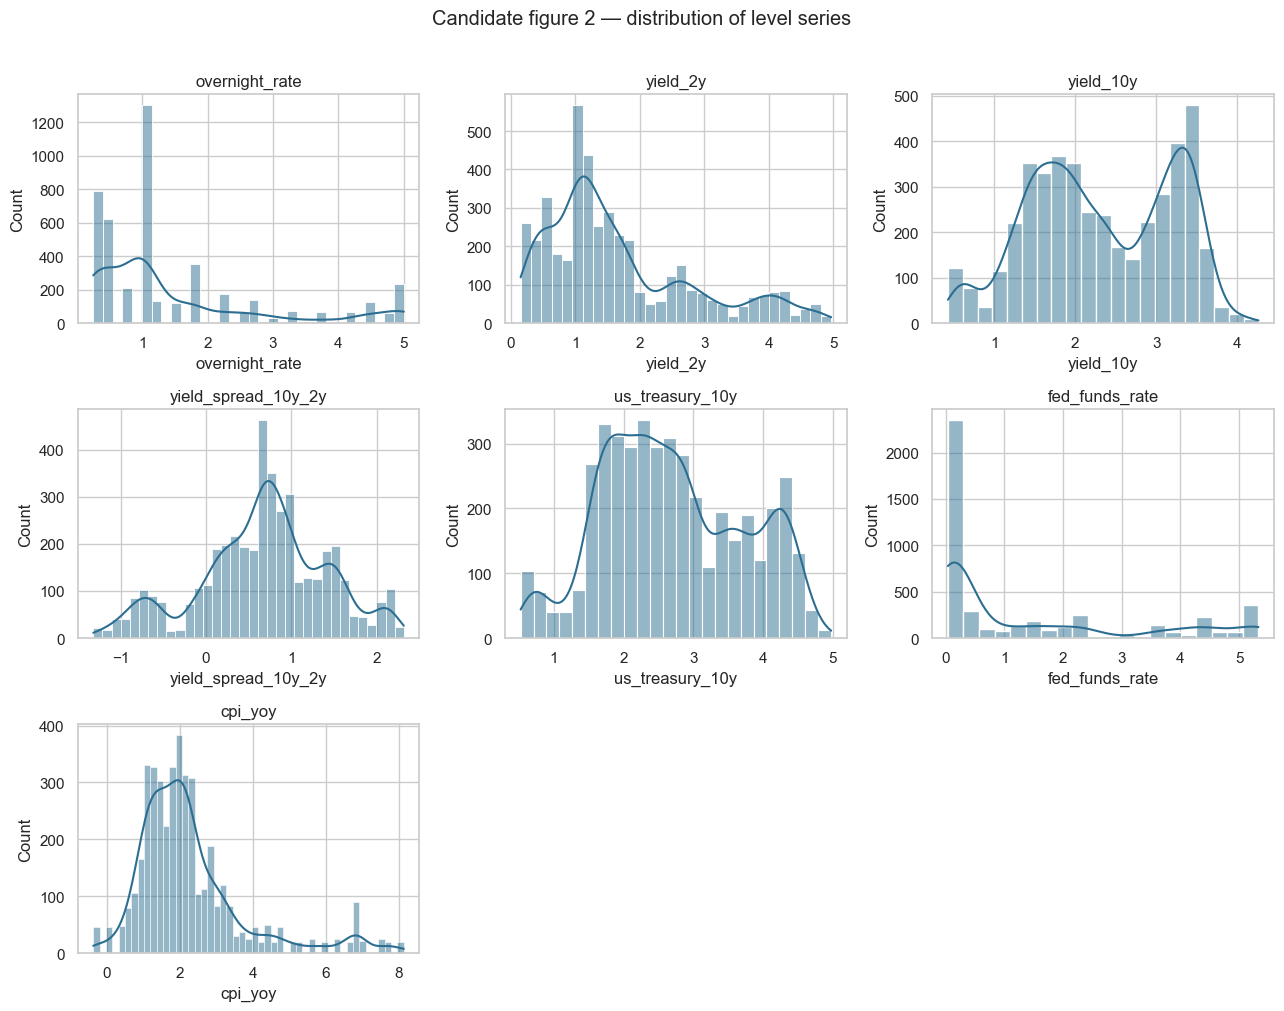

In [6]:
level_cols = [
    "overnight_rate", "yield_2y", "yield_10y", "yield_spread_10y_2y",
    "us_treasury_10y", "fed_funds_rate", "cpi_yoy",
]
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.ravel(), level_cols):
    sns.histplot(daily[col].dropna(), kde=True, ax=ax, color="#2c6e91")
    ax.set_title(col)
for ax in axes.ravel()[len(level_cols):]:
    ax.axis("off")
fig.suptitle("Candidate figure 2 — distribution of level series", y=1.01)
fig.tight_layout()
plt.show()


**Interpretation:** `overnight_rate` and `fed_funds_rate` are bimodal — a long near-zero mode
(2009–2021, ZIRP-era policy) and a second mode above 4% (post-2022 hiking cycle), not a smooth
unimodal distribution. `yield_spread_10y_2y` is centered near zero but has a visible left tail —
those are the inversion episodes worth flagging for the report, not outliers to clean out.


## 6. Correlation — levels vs. first differences

Pearson correlation on **levels** of trending, non-stationary series is a well-known trap: two
unrelated random walks will show high correlation purely because both drift over time. The levels
heatmap is shown first because it's the naive thing to reach for, then the differenced version
right after — that's the one that should actually inform modeling choices.


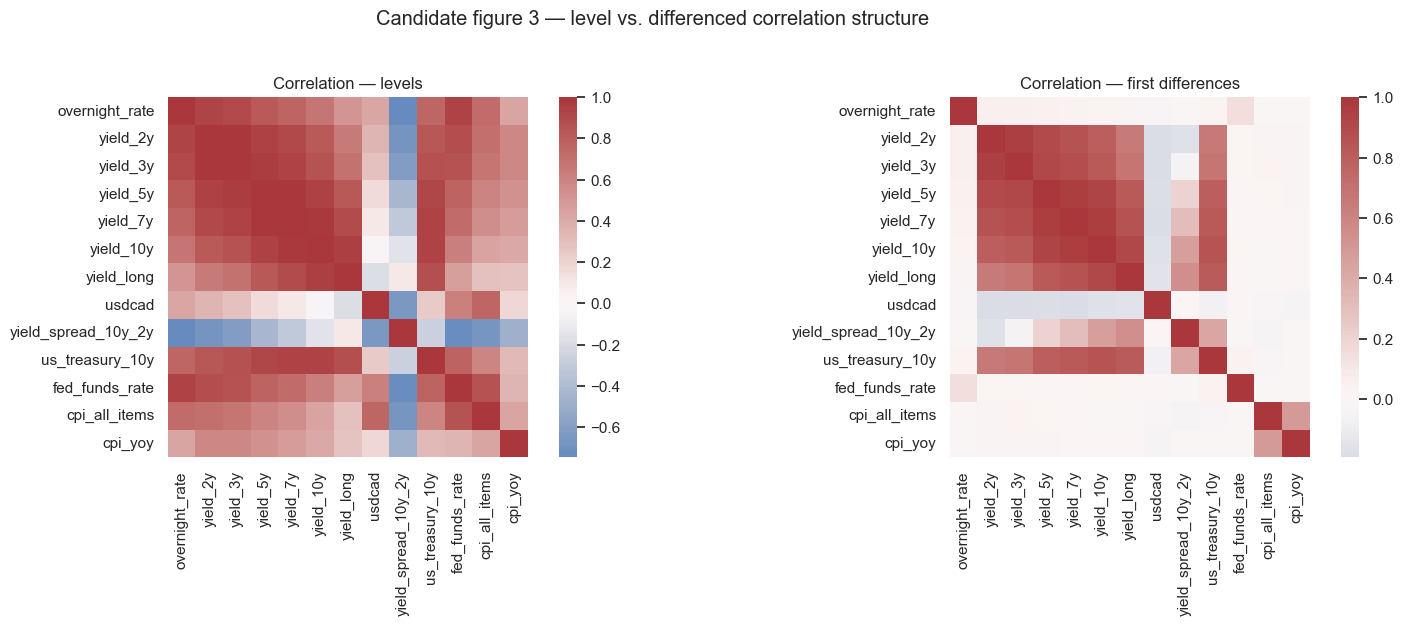

In [7]:
diff_cols = [c for c in daily.columns if c not in ("usdcad_legacy", "usdcad_current")]
levels = daily[diff_cols].dropna()
diffs = daily[diff_cols].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(levels.corr(), cmap="vlag", center=0, ax=axes[0], square=True)
axes[0].set_title("Correlation — levels")
sns.heatmap(diffs.corr(), cmap="vlag", center=0, ax=axes[1], square=True)
axes[1].set_title("Correlation — first differences")
fig.suptitle("Candidate figure 3 — level vs. differenced correlation structure", y=1.03)
fig.tight_layout()
plt.show()


**Interpretation:** in levels, almost everything is highly correlated (>0.8) with almost
everything else — including CPI against yields, which is not a claim anyone should walk into
Round 3 modeling believing at face value. In first differences the structure is much sparser and
more plausible: the BoC yield tenors move tightly together (as expected — one curve), and
`us_treasury_10y` co-moves with `yield_10y` (US/CA rate linkage), but CPI's daily change is
essentially uncorrelated with everything, consistent with it being a step function between
monthly releases.


## 7. ADF stationarity pre-checks

This is the section most directly useful outside this notebook: issues #22/#23 and PRs #33/#34
are actively deciding whether VECM belongs in the model suite, and VECM only makes sense if the
underlying series are integrated (I(1)) *and* cointegrated. This table doesn't settle
cointegration (that needs a Johansen test against a specific model spec, which is Round 3's job),
but it does establish the more basic precondition: are these series even I(1) in the first place.


In [8]:
def adf_row(series, label):
    series = series.dropna()
    stat, pval, *_ = adfuller(series, autolag="AIC")
    return {"series": label, "adf_stat": round(stat, 3), "p_value": round(pval, 4),
            "stationary_at_5pct": pval < 0.05}

rows = []
for col in diff_cols:
    rows.append(adf_row(daily[col], f"{col} (level)"))
    rows.append(adf_row(daily[col].diff(), f"{col} (first diff)"))

adf_table = pd.DataFrame(rows)
adf_table


,series,adf_stat,p_value,stationary_at_5pct
0,overnight_rate (level),-1.212,0.6682,False
1,overnight_rate (first diff),-8.189,0.0000,True
2,yield_2y (level),-1.175,0.6842,False
3,yield_2y (first diff),-37.667,0.0000,True
4,yield_3y (level),-1.257,0.6484,False
5,yield_3y (first diff),-37.910,0.0000,True
6,yield_5y (level),-1.559,0.5043,False
7,yield_5y (first diff),-37.660,0.0000,True
8,yield_7y (level),-1.690,0.4362,False
9,yield_7y (first diff),-63.846,0.0000,True


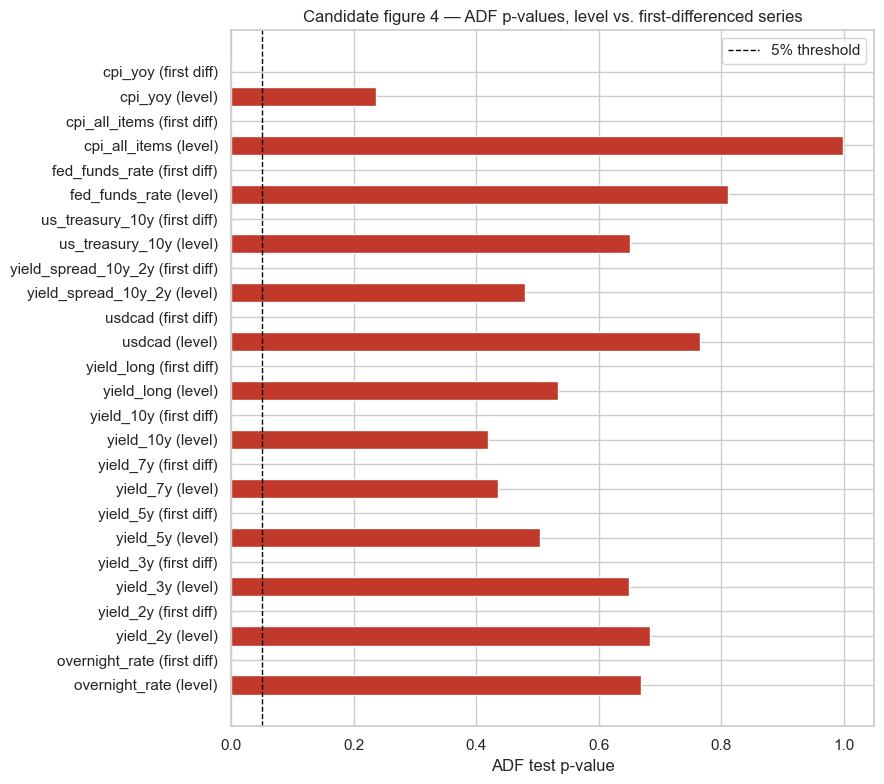

In [9]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = adf_table["stationary_at_5pct"].map({True: "#2e7d32", False: "#c0392b"})
ax.barh(adf_table["series"], adf_table["p_value"], color=colors)
ax.axvline(0.05, color="black", linestyle="--", linewidth=1, label="5% threshold")
ax.set_xlabel("ADF test p-value")
ax.set_title("Candidate figure 4 — ADF p-values, level vs. first-differenced series")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretation:** every level series fails to reject the unit-root null (p > 0.05) and every
first-differenced series rejects it cleanly (p ≈ 0) — the textbook I(1) pattern, and the reason
Round 3's VAR baselines need to run on differenced (or otherwise stationarity-corrected) data, not
raw levels.

One result worth being precise about rather than over-reading: `yield_spread_10y_2y` in levels
(p = 0.48) is **not** a standout — it sits inside the same 0.42–0.81 range as every other yield
level, not meaningfully lower. A spread being stationary while its components are each I(1) would
be a classic cointegration signature, but ADF on the spread alone doesn't establish that here; it
would need an actual Johansen test against a specific VAR/VECM spec, which is Round 3's job, not
something to claim off this table. Flagging it as a candidate to check in Round 3, not as a
finding.


## 8. Multicollinearity (VIF) — Issue #67

`data/processed/gold_features.csv` carries `yield_2y`/`yield_5y`/`yield_10y` alongside all three
pairwise spreads (`yield_spread_10y_2y`, `yield_spread_10y_5y`, `yield_spread_5y_2y`) — these
aren't just correlated, they're exact linear combinations
(`yield_spread_10y_2y === yield_10y - yield_2y === yield_spread_10y_5y + yield_spread_5y_2y`).
No VIF check exists anywhere in this repo to catch a future feature-set change that combines
columns from this dependent set. `compute_vif()` (`src/diagnostics.py`) is that check, applied
here to every feature set an actual model fits on, plus a demonstration of what it would report
if a future change re-introduced the dependency.

In [10]:
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from diagnostics import compute_vif

gold = pd.read_csv(PROCESSED / "gold_features.csv", parse_dates=["date"]).set_index("date")

# VAR-AIC (#28), VAR-BIC (#29) and LSTM (#49) all fit this same differenced 6-variable set
# (src/EDA_VAR_AIC _lag _order.py's FEATURE_SET, src/lstm_baseline.py's FEATURES) -- one spread
# column, no overlapping yield levels.
diff_6var = ["d_yield_spread_10y_2y", "d_overnight_rate", "d_us_treasury_10y",
             "d_fed_funds_rate", "d_cpi_yoy", "d_usdcad"]
vif_diff_6var = compute_vif(gold, diff_6var)
vif_diff_6var

,feature,vif
0,d_us_treasury_10y,1.241306
1,d_yield_spread_10y_2y,1.233572
2,d_overnight_rate,1.023360
3,d_fed_funds_rate,1.022630
4,d_usdcad,1.009598
5,d_cpi_yoy,1.003008


In [11]:
# VECM (#47) fits in levels, both systems it actually reports (src/johansen_vecm.py's
# FEATURE_SET_5VAR/FEATURE_SET_6VAR) -- same one-spread-column shape as the differenced set above.
level_5var = ["yield_spread_10y_2y", "overnight_rate", "us_treasury_10y", "fed_funds_rate", "cpi_yoy"]
level_6var = level_5var + ["usdcad"]

vif_level_5var = compute_vif(gold, level_5var)
vif_level_6var = compute_vif(gold, level_6var)
print("5-variable system:")
display(vif_level_5var)
print("6-variable system (+ usdcad):")
display(vif_level_6var)

5-variable system:


,feature,vif
0,fed_funds_rate,16.534513
1,overnight_rate,11.118227
2,us_treasury_10y,8.810522
3,yield_spread_10y_2y,8.537717
4,cpi_yoy,1.848829


6-variable system (+ usdcad):


,feature,vif
0,fed_funds_rate,30.686877
1,overnight_rate,23.429303
2,yield_spread_10y_2y,10.161649
3,us_treasury_10y,8.821068
4,usdcad,4.490294
5,cpi_yoy,1.849146


In [12]:
# Guard demonstration, not a currently-fit feature set: what VIF reports if a future change
# combines yield levels with more than one spread column from the same dependent set.
overlapping_cols = [
    "yield_2y", "yield_5y", "yield_10y",
    "yield_spread_10y_2y", "yield_spread_10y_5y", "yield_spread_5y_2y",
]

# compute_vif() reports rank-deficient columns as an explicit np.inf (matrix_rank check)
# rather than calling variance_inflation_factor's OLS inversion on them, so this no longer
# triggers the RuntimeWarning divide-by-zero that used to need suppressing here.
vif_overlapping = compute_vif(gold, overlapping_cols)
vif_overlapping

,feature,vif
0,yield_2y,inf
1,yield_5y,inf
2,yield_10y,inf
3,yield_spread_10y_2y,inf
4,yield_spread_10y_5y,inf
5,yield_spread_5y_2y,inf


**Interpretation:** two different results here, not one.

The **differenced** 6-variable set VAR-AIC, VAR-BIC, and LSTM all actually fit on reports VIF
between 1.00 and 1.24 for every regressor — clean, no collinearity concern.

The **level** feature sets VECM (#47) actually fits on are a different story: `fed_funds_rate`
(VIF 16.5 / 30.7 in the 5-/6-variable systems) and `overnight_rate` (11.1 / 23.4) both clear the
conventional "serious concern" threshold of 10, and `us_treasury_10y` / `yield_spread_10y_2y` sit
in the 8.5–10.2 range right at it. This is expected structurally, not a bug: these are non-stationary
I(1) level series that share common trends (multiple policy/market interest rates moving together
over the sample) — the same common-trend property Johansen/VECM is built to exploit via
cointegration, not a defect to regularize away like it would be in an ordinary OLS regression on
presumably-independent regressors. It's a genuinely different phenomenon from the exact linear
redundancy issue #67 was filed about (confirmed absent above: no current feature set combines more
than one yield/spread column), but it's real and worth the team knowing about when interpreting
VECM's β/α coefficient stability.

Worth being precise about what these level-set VIF numbers *are*, methodologically: standard VIF is
an OLS-model diagnostic, and OLS on non-stationary I(1) levels is itself a textbook trap — the
regression can look strong (high R², "significant" coefficients) purely because unrelated
random-walk series drift together, not because of any real relationship (Granger & Newbold, 1974).
That means static OLS VIF on these level sets is *mechanically* inflated by the same shared-trend
mechanism, not an independent second signal on top of it. VIF here is diagnostic color, not the
authoritative test: the actual econometric question — are these series jointly stationary in some
linear combination — is answered by the Johansen cointegration rank test against VECM's specific
model spec, not by VIF thresholds designed for cross-sectional OLS regressors. Section 7 already
flags this as Round 3's job to run; the VIF numbers above shouldn't be read as a substitute for it.

The **guard demonstration** confirms issue #67's specific concern: mixing yield levels with more
than one spread column from the same dependent set sends VIF to (numerically) infinity, exactly as
described. No current feature set does this — the exact-redundancy risk is real but not currently
triggered — but there's still no guard stopping a future feature-set change from re-introducing it.

**Reference:** Granger, C. W. J., & Newbold, P. (1974). Spurious regressions in econometrics.
*Journal of Econometrics*, 2(2), 111–120.

## 9. Summary for the team

- **Built on:** Round 1 Path A only (Giti's PR #35) — Path B doesn't exist yet, so this isn't a
  judged comparison.
- **Yield curve overview** (section 4) shows two inversion windows in-sample — brief in 2019, then
  repeated flip-flopping across zero from mid-2022 through late 2024 — directly relevant to the
  inversion-as-leading-indicator framing in `proposal/sections/05_analytical_approach.md` §5.1. As
  of the last observation (2026-06-30) the curve is upward-sloping and not inverted.
- **CPI YoY is computed at monthly frequency** (`pct_change(12)` on the reference-month-ordered
  series, joined on `release_date`, then forward-filled) rather than `pct_change(252)` on the
  forward-filled daily series — the daily version divides by a varying count of business days per
  year and produces spurious jumps.
- **Missingness** is explainable: USD/CAD legacy/current split, CPI release-date alignment, and a
  small number of holiday-calendar mismatches. Nothing here blocks Round 3.
- **Don't correlate levels** — the differenced correlation heatmap (section 6) is the one to trust
  for any variable-selection decisions.
- **All rate/yield series are I(1)** (section 7); Round 3 VAR baselines should run on
  differences. ADF alone doesn't establish cointegration for any pair (including
  `yield_spread_10y_2y`, which is not a standout in this table) — that needs an actual Johansen
  test in Round 3, relevant to the open #22/#23 VECM discussion.
- **Round 2 team sync** (originally Fri Jul 31 per `M2_CHECKLIST.md`) has already passed as of
  this notebook — flagging so the team can confirm whether it happened and record the decision.
- **Oral presentation practice Q&A** — practice questions and model answers corresponding to these EDA sections are maintained in [`docs/EDA_PRESENTATION_QA.md`](../../docs/EDA_PRESENTATION_QA.md) for team rehearsal.
